# Q2 - Multi-Agent LangGraph Workflow

本Notebook包含一个完整的agent系统流程。Run All以运行所有code cell并展示输出结果。


## 结果索引
- 依赖与外部API: **Cell 1**
- 数据概览: **Cell 4**
- 训练日志: **Cell 6**
- 评估指标 (AUC/Precision/Recall/F1): **Cell 7**
- 可视化 (Confusion矩阵 / ROC曲线 / 模型评估指标对比): **Cell 8**
- 数据泄露检测: **Cell 9**


In [ ]:
# One-click setup: install dependencies + optional API key
%pip install -r ./code/requirements.txt

import os

# This pipeline can use DeepSeek LLM for data-cleaning planning.
# Fill your key below. If key is empty/invalid or connection fails,
# the pipeline will automatically fall back to Rule Planner.
DEEPSEEK_API_KEY = ""  # e.g. "sk-xxx"
if DEEPSEEK_API_KEY.strip():
    os.environ['DEEPSEEK_API_KEY'] = DEEPSEEK_API_KEY.strip()

print('DEEPSEEK_API_KEY detected =', 'yes' if os.getenv('DEEPSEEK_API_KEY') else 'no')


Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple

[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
DEEPSEEK_API_KEY detected = yes


In [2]:
import sys, platform
import numpy as np
import pandas as pd
import sklearn

print('Python:', sys.version)
print('Platform:', platform.platform())
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)
try:
    import xgboost as xgb
    print('xgboost:', xgb.__version__)
except Exception as e:
    print('xgboost: not available ->', e)

Python: 3.11.11 (main, Jan 16 2026, 16:27:43) [GCC 11.4.0]
Platform: Linux-5.10.134-17.3.al8.x86_64-x86_64-with-glibc2.35
numpy: 2.4.2
pandas: 3.0.1
scikit-learn: 1.8.0
xgboost: 2.1.4


In [3]:
from pathlib import Path
import json
import sys
sys.path.append(str(Path('./code').resolve()))
from notebook_helpers import run_pipeline, load_result, model_metrics_table

DATA_PATH = Path('../data.pq')
TARGET = 'Y1'
OUTPUT_DIR = Path('./ml_pipeline_outputs')
SCRIPT_PATH = Path('./code/multi_agent_langgraph_pipeline.py')

assert DATA_PATH.exists(), f'data file not found: {DATA_PATH.resolve()}'
assert SCRIPT_PATH.exists(), f'script not found: {SCRIPT_PATH.resolve()}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_PATH =', DATA_PATH.resolve())
print('TARGET    =', TARGET)
print('OUTPUT_DIR=', OUTPUT_DIR.resolve())
print('SCRIPT    =', SCRIPT_PATH.resolve())

DATA_PATH = /mnt/workspace/tenxai/data.pq
TARGET    = Y1
OUTPUT_DIR= /mnt/workspace/tenxai/Q2/ml_pipeline_outputs
SCRIPT    = /mnt/workspace/tenxai/Q2/code/multi_agent_langgraph_pipeline.py


In [4]:
# Data overview output

df = pd.read_parquet(DATA_PATH)
print('shape =', df.shape)
print('columns =', len(df.columns))
print('target distribution:')
print(df[TARGET].value_counts(dropna=False).sort_index())

overview_path = OUTPUT_DIR / 'data_overview.md'
if overview_path.exists():
    print('\n[data_overview.md preview]')
    txt = overview_path.read_text(encoding='utf-8')
    print('\n'.join(txt.splitlines()[:40]))
else:
    print('data_overview.md will be generated after pipeline run.')


shape = (81046, 321)
columns = 321
target distribution:
Y1
-1.0    58257
 0.0    11010
 1.0    11779
Name: count, dtype: int64
data_overview.md will be generated after pipeline run.


In [5]:
# Run full pipeline (LLM planner is auto-detected from DEEPSEEK_API_KEY)
run_info = run_pipeline(SCRIPT_PATH, DATA_PATH, TARGET, OUTPUT_DIR)
print(run_info['stdout'])
if run_info['stderr']:
    print('\n[stderr]')
    print(run_info['stderr'])
print('returncode =', run_info['returncode'])


This agent system can use the DeepSeek LLM for data-cleaning planning. Set DEEPSEEK_API_KEY before running (for notebook, set it in the install/setup cell). If key is missing or connection fails, the pipeline will auto-fallback to Rule Planner.
Startup check: scanning DEEPSEEK_API_KEY for LLM planner.
Detected DEEPSEEK_API_KEY: yes
Planner mode: LLM planner enabled (DeepSeek, preflight passed)
[2026-03-01T11:05:17] Read data started: loading parquet from ../data.pq
[2026-03-01T11:05:17] Read parquet done: rows=81046, cols=321, x_features=300
[2026-03-01T11:05:17] Output directory ready: ml_pipeline_outputs
[2026-03-01T11:05:17] Generating target distribution figure...
[2026-03-01T11:05:17] Target distribution figure done
[2026-03-01T11:05:17] Building pandas data overview markdown...
[2026-03-01T11:05:18] Data overview markdown done: data_overview.md
[2026-03-01T11:05:18] Computing missing ratio over all X features...
[2026-03-01T11:05:19] Missing ratio all-features bar chart done
[202

In [6]:
# Training process logs (full)
result_path = OUTPUT_DIR / 'langgraph_pipeline_result.json'
assert result_path.exists(), f'result json not found: {result_path}'
result = load_result(result_path)

# Prefer English key; keep backward-compatible fallback.
logs = result.get('run_logs', result.get('\u8fd0\u884c\u65e5\u5fd7', []))
print('all logs count =', len(logs))
for line in logs:
    print(line)


all logs count = 86
[2026-03-01T11:05:17] Read data started: loading parquet from ../data.pq
[2026-03-01T11:05:17] Read parquet done: rows=81046, cols=321, x_features=300
[2026-03-01T11:05:17] Output directory ready: ml_pipeline_outputs
[2026-03-01T11:05:17] Generating target distribution figure...
[2026-03-01T11:05:17] Target distribution figure done
[2026-03-01T11:05:17] Building pandas data overview markdown...
[2026-03-01T11:05:18] Data overview markdown done: data_overview.md
[2026-03-01T11:05:18] Computing missing ratio over all X features...
[2026-03-01T11:05:19] Missing ratio all-features bar chart done
[2026-03-01T11:05:19] Generating missing ratio histogram...
[2026-03-01T11:05:19] Missing ratio histogram done
[2026-03-01T11:05:19] Skipping missingness correlation heatmap by design
[2026-03-01T11:05:19] Read data complete: shape=(81046, 321), target=Y1
[2026-03-01T11:05:19] LLM Planner started
[2026-03-01T11:05:27] LLM Planner plan accepted (attempt=1)
[2026-03-01T11:05:27] L

In [7]:
# Metrics output (AUC/Precision/Recall/F1/Accuracy)
metrics_df = model_metrics_table(result)
try:
    display(metrics_df)
except NameError:
    print(metrics_df)


,auc,precision,recall,f1,accuracy
2,0.940769,0.754021,0.814398,0.779623,0.817296
1,0.942579,0.760503,0.774417,0.765246,0.816371
0,0.907812,0.754752,0.579297,0.547424,0.760609



 model_comparison.png


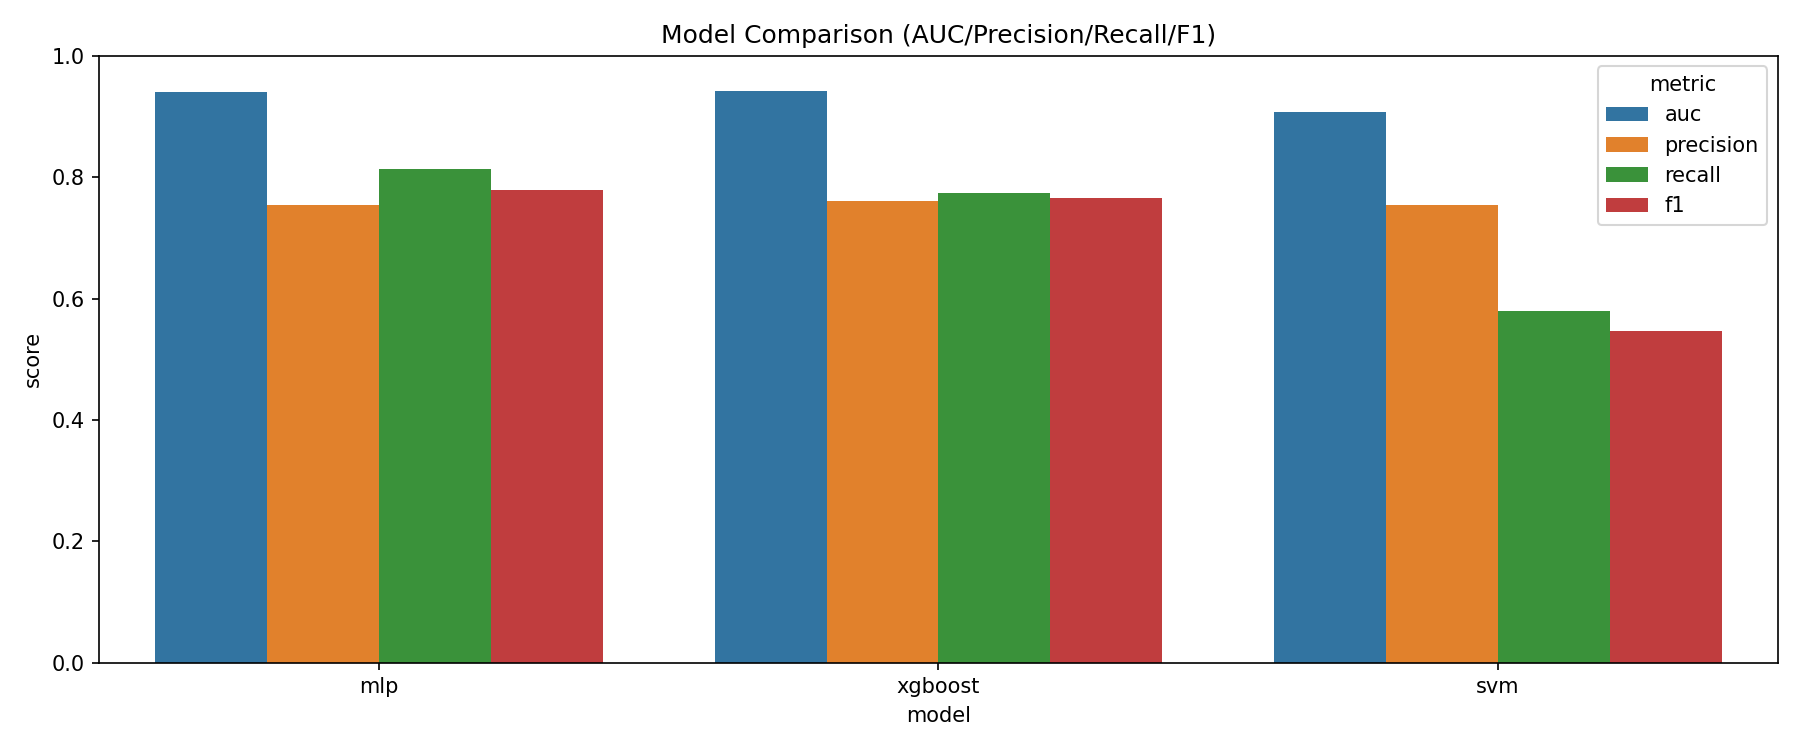


 svm_confusion_matrix.png


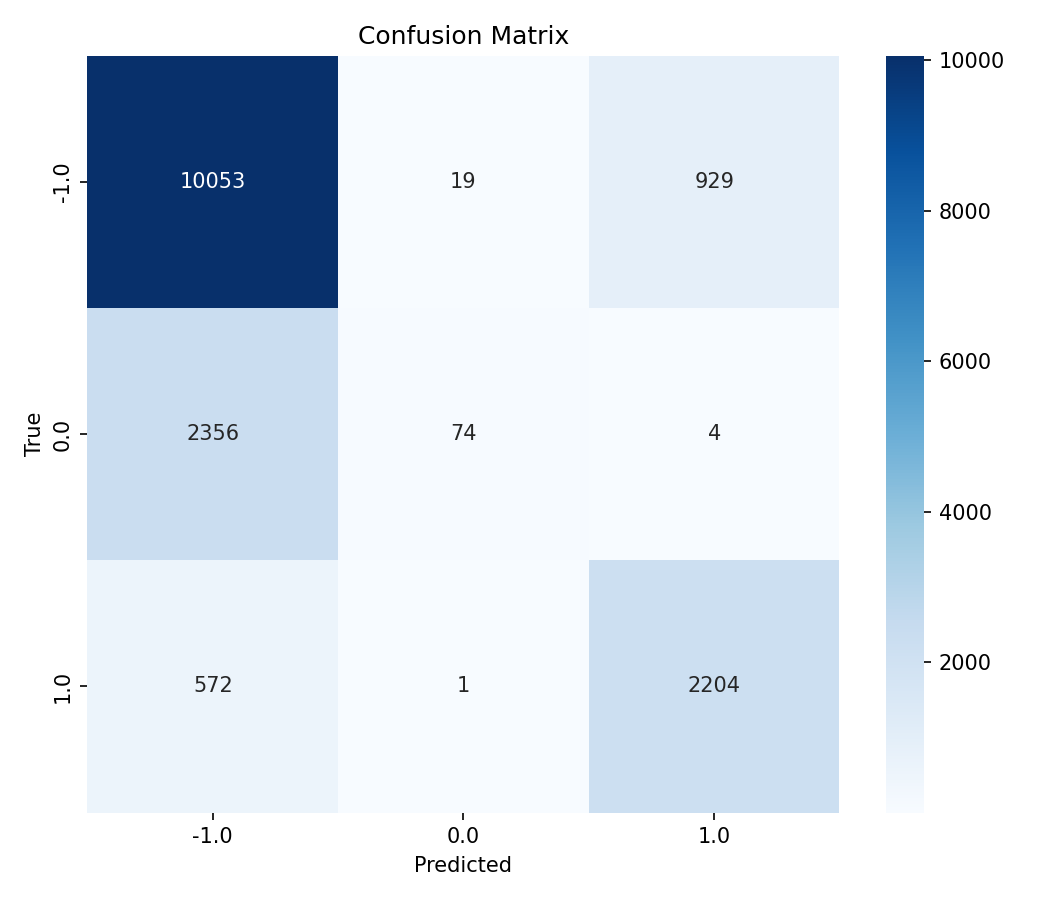


 svm_roc_curve.png


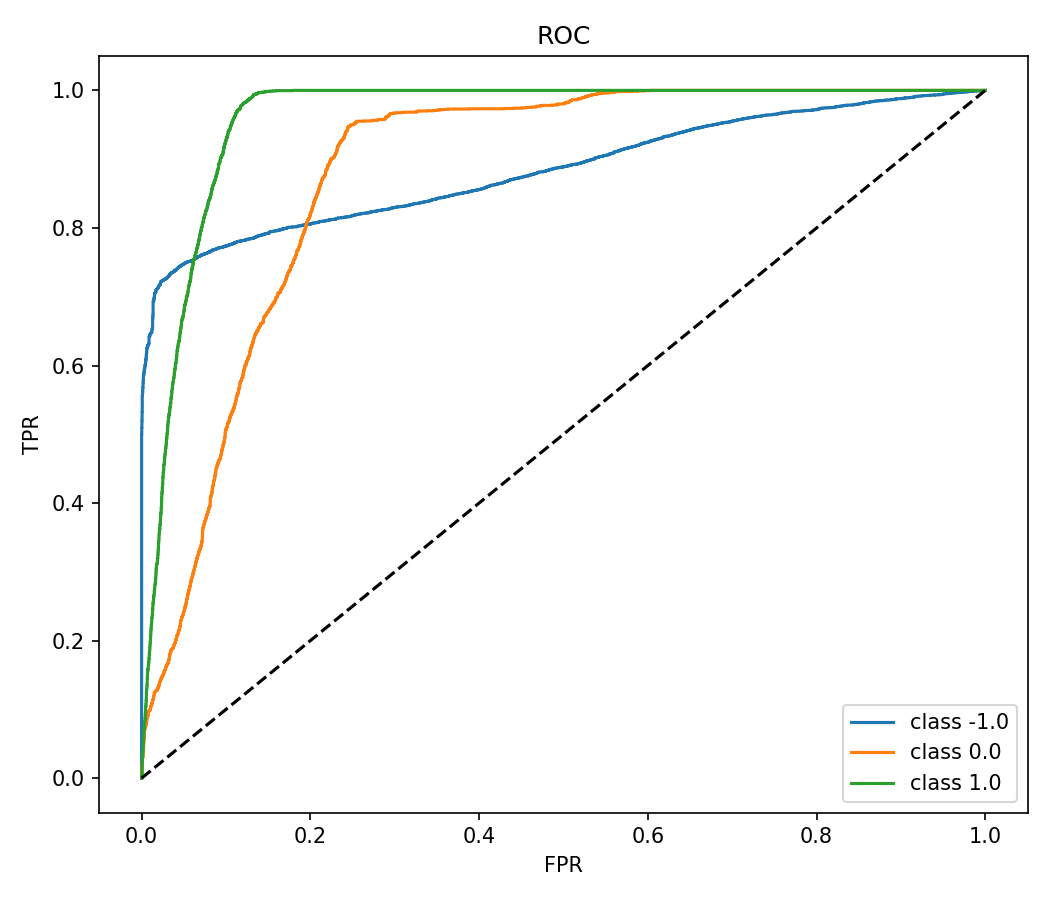


 xgboost_confusion_matrix.png


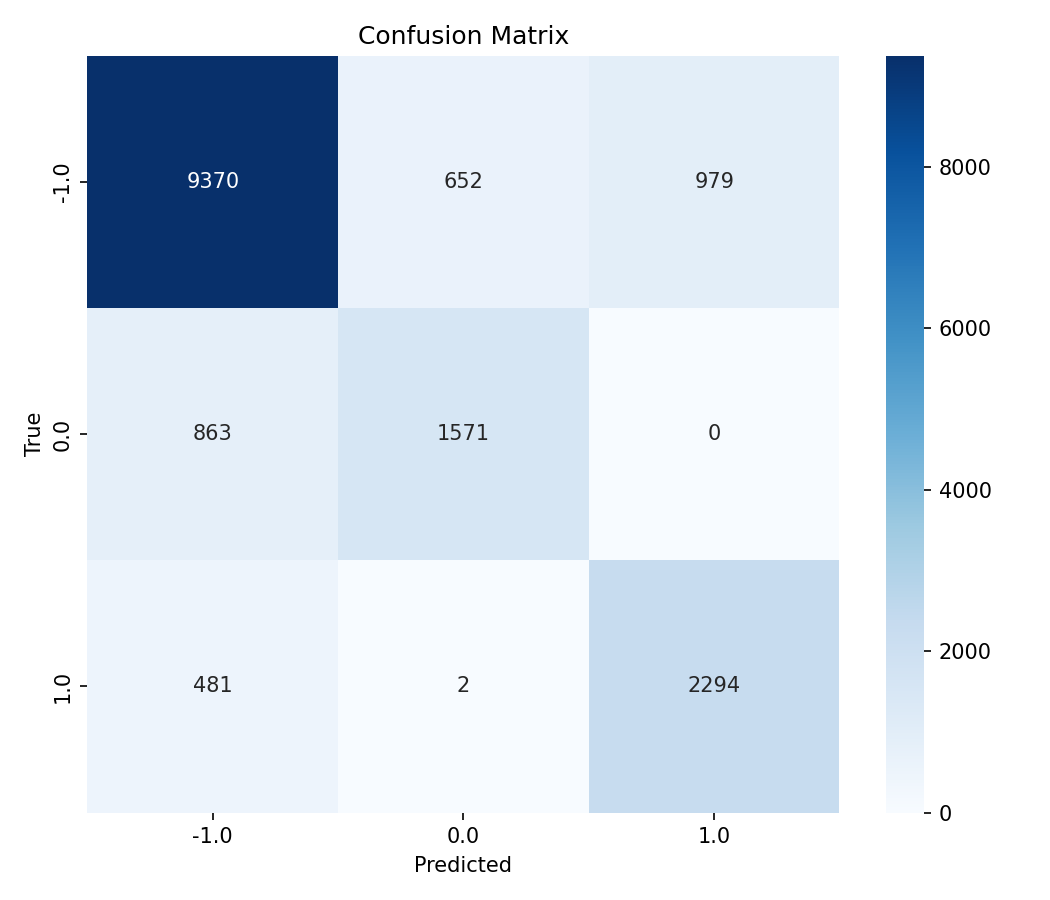


 xgboost_roc_curve.png


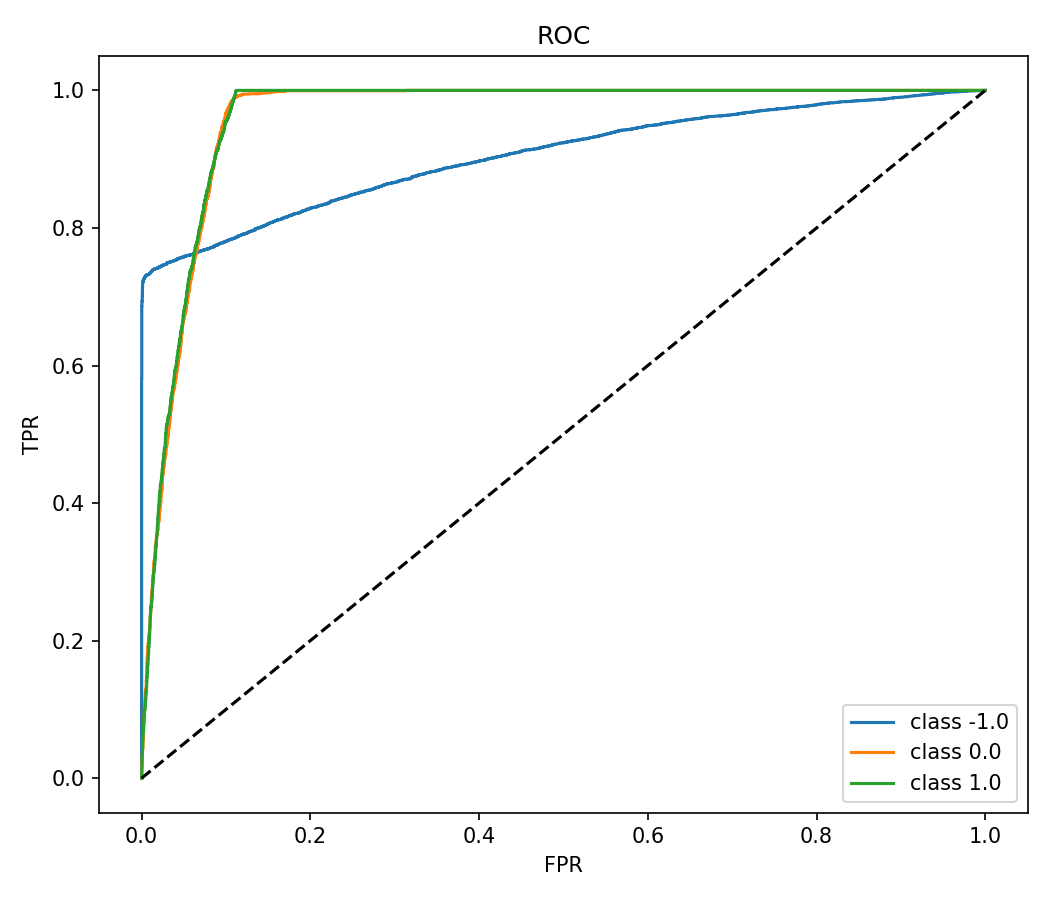


 mlp_confusion_matrix.png


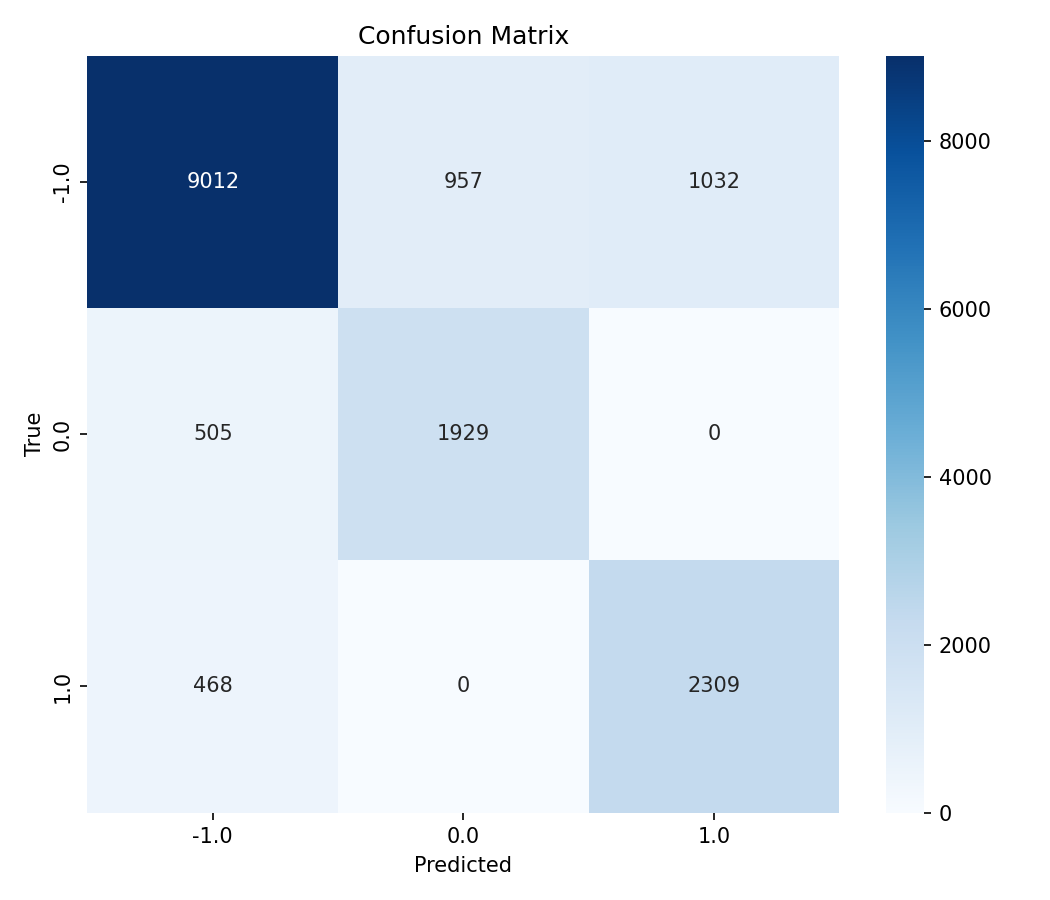


 mlp_roc_curve.png


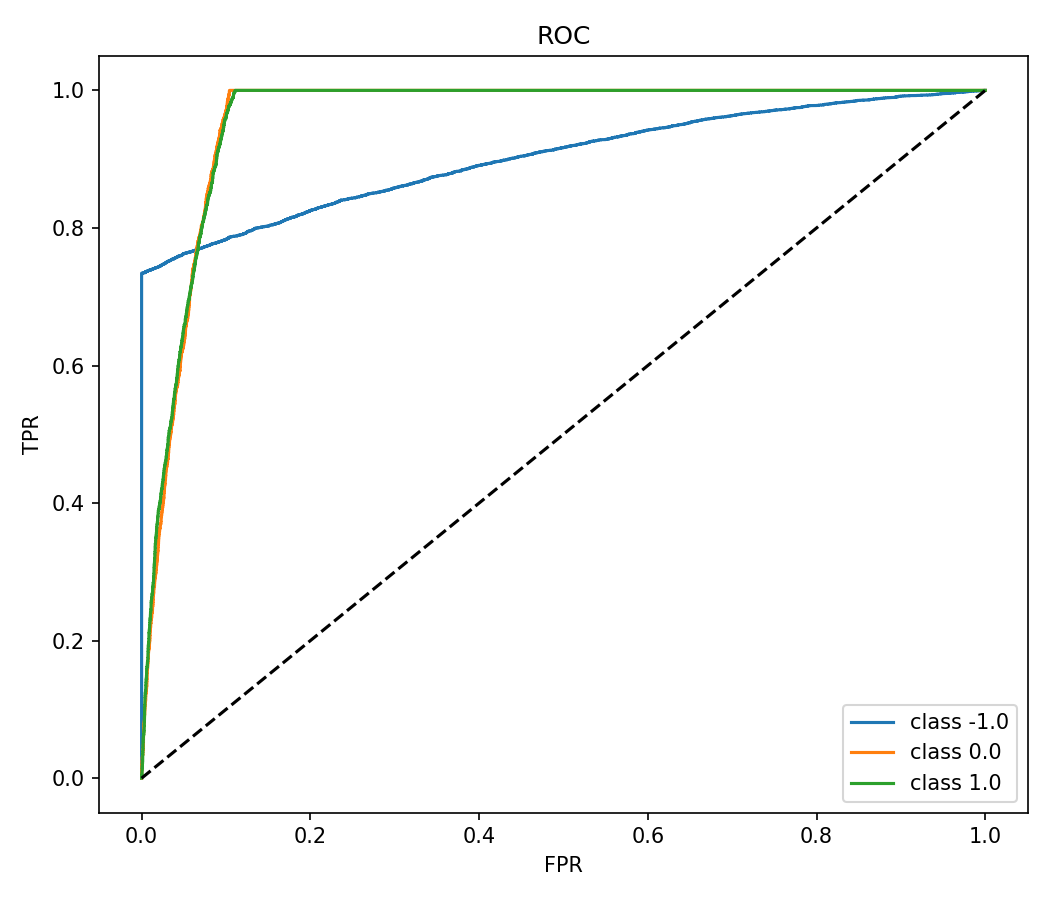

In [8]:
# Visualization output (Confusion Matrix / ROC / Comparison)
from IPython.display import Image, display

images = [
    'model_comparison.png',
    'svm_confusion_matrix.png', 'svm_roc_curve.png',
    'xgboost_confusion_matrix.png', 'xgboost_roc_curve.png',
    'tree_fallback_confusion_matrix.png', 'tree_fallback_roc_curve.png',
    'mlp_confusion_matrix.png', 'mlp_roc_curve.png',
]
for name in images:
    img = OUTPUT_DIR / name
    if img.exists():
        print('\n', name)
        display(Image(filename=str(img)))


In [9]:
# Data leakage check output
# Prefer new English key; keep backward-compatible fallback.
leak = result.get(
    'model_evaluation_and_temporal_leakage',
    result.get('temporal_leakage_check', result.get('\u65f6\u5e8f\u6cc4\u6f0f\u68c0\u6d4b', {})),
)
print(json.dumps(leak, ensure_ascii=False, indent=2))


{
  "model_evaluation_files_directory": "ml_pipeline_outputs",
  "has_time_data": true,
  "leakage_detected": false,
  "max_train_time": "2019-12-25 00:00:00",
  "min_test_time": "2019-12-26 00:00:00",
  "overlap_count": 0,
  "message": "No leakage detected"
}
